# VOC multi-label model 

Assisngemnt BY : Siraj Ahmed 023-22-0144
Jahnazaib Sheihk : 023-22-0069

This notebook **uses exactly 100 Pascal VOC images**:
- **50** for training  
- **25** for validation (during training)  
- **25** for testing (held-out; reported after training)  

It trains a pretrained CNN head for **multi-label** prediction (20 VOC classes), prints **validation and test metrics**, and reports **accuracy** (Hamming accuracy and strict subset accuracy).

### Where images are loaded from

- Files like `datasets/VOC/images/train2007/000012.jpg` and `.../test2007/000002.jpg` are **the same VOC images** as in the official tree; YOLO just stores them in split folders.
- **`torchvision.datasets.VOCDetection`** reads images + XML labels from **`DATA_ROOT/VOCdevkit/VOC2007/`** (you already have this under `datasets/VOC/images/VOCdevkit/`).
- The notebook checks **`datasets/VOC/images` first**, then `./data`. **If `VOCdevkit/VOC2007` exists there, nothing is downloaded.** A download happens only when neither location has that folder.

In [1]:
%pip -q install torch torchvision tqdm scikit-learn matplotlib pandas pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Al Masoom Trader\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [14]:
import random
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.datasets import VOCDetection

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from sklearn.metrics import precision_recall_fscore_support


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

Device: cpu
Torch: 2.11.0+cpu


In [15]:
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(VOC_CLASSES)}
NUM_CLASSES = len(VOC_CLASSES)


def voc_annotation_to_multihot(annotation: dict) -> torch.Tensor:
    objects = annotation.get("annotation", {}).get("object", [])
    if isinstance(objects, dict):
        objects = [objects]
    y = torch.zeros(NUM_CLASSES, dtype=torch.float32)
    for obj in objects:
        name = obj.get("name")
        if name in CLASS_TO_IDX:
            y[CLASS_TO_IDX[name]] = 1.0
    return y


class VOCSubsetMultiLabel(Dataset):
    """Subset of one shared VOCDetection (image paths may be patched for YOLO-style folders)."""

    def __init__(self, voc_ds: VOCDetection, indices: List[int], transform):
        self.ds = voc_ds
        self.indices = list(indices)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, i: int):
        img, ann = self.ds[self.indices[i]]
        y = voc_annotation_to_multihot(ann)
        if self.transform is not None:
            img = self.transform(img)
        return img, y

In [16]:
# Exactly 100 images: 50 train / 25 val / 25 test
from pathlib import Path

# TorchVision expects ROOT/VOCdevkit/VOC2007/ — same dataset as train2007/test2007 jpgs, different layout.
DATA_ROOT = None
for _root in (Path("datasets/VOC/images"), Path("data")):
    if (_root / "VOCdevkit" / "VOC2007").is_dir():
        DATA_ROOT = str(_root.resolve())
        break
if DATA_ROOT is None:
    DATA_ROOT = str(Path("datasets/VOC/images").resolve())

_voc_layout = Path(DATA_ROOT) / "VOCdevkit" / "VOC2007"
_need_download = not _voc_layout.is_dir()
if _need_download:
    print("VOCdevkit not found — will download under:", DATA_ROOT)
else:
    print("Using local VOC (no download):", _voc_layout)

VOC_YEAR = "2007"
IMAGE_SET = "trainval"

N_TOTAL = 100
N_TRAIN, N_VAL, N_TEST = 50, 25, 25
assert N_TRAIN + N_VAL + N_TEST == N_TOTAL

IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 25

rng = np.random.RandomState(42)
_voc_full = VOCDetection(root=DATA_ROOT, year=VOC_YEAR, image_set=IMAGE_SET, download=_need_download)
_jpeg_dir = Path(DATA_ROOT) / "VOCdevkit" / f"VOC{VOC_YEAR}" / "JPEGImages"
_images_parent = Path(DATA_ROOT)
_split_subdirs = ("train2007", "val2007", "test2007")

_valid_indices = []
for i in range(len(_voc_full)):
    img_id = Path(_voc_full.images[i]).stem
    resolved = None
    for sub in _split_subdirs:
        p = _images_parent / sub / f"{img_id}.jpg"
        if p.is_file():
            resolved = str(p.resolve())
            break
    if resolved is None:
        p = _jpeg_dir / f"{img_id}.jpg"
        if p.is_file():
            resolved = str(p.resolve())
    if resolved is not None:
        _voc_full.images[i] = resolved
        _valid_indices.append(i)

_missing = len(_voc_full) - len(_valid_indices)
if _missing:
    print(
        f"Warning: {_missing} id(s) in {IMAGE_SET} have no JPEG under VOCdevkit/JPEGImages nor {DATA_ROOT}/train2007|val2007|test2007. "
        "Skipping those ids."
    )
if len(_valid_indices) < N_TOTAL:
    raise RuntimeError(
        f"Only {len(_valid_indices)} JPEGs found but need {N_TOTAL}. "
        "Re-extract VOC2007 so JPEGImages matches ImageSets, or use a complete VOCdevkit."
    )

perm = rng.permutation(len(_valid_indices))
chosen = [_valid_indices[j] for j in perm[:N_TOTAL]]
train_indices = chosen[:N_TRAIN]
val_indices = chosen[N_TRAIN : N_TRAIN + N_VAL]
test_indices = chosen[N_TRAIN + N_VAL :]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = VOCSubsetMultiLabel(_voc_full, train_indices, train_tfms)
val_ds = VOCSubsetMultiLabel(_voc_full, val_indices, eval_tfms)
test_ds = VOCSubsetMultiLabel(_voc_full, test_indices, eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print(
    f"VOC {VOC_YEAR} {IMAGE_SET}: {len(_voc_full)} ids in split list, "
    f"{len(_valid_indices)} JPEGs on disk"
)
print(f"Using exactly {N_TOTAL} images → train {len(train_ds)}, val {len(val_ds)}, test {len(test_ds)}")

Using local VOC (no download): D:\projects\Semester\datasets\VOC\images\VOCdevkit\VOC2007
VOC 2007 trainval: 5011 ids in split list, 5011 JPEGs on disk
Using exactly 100 images → train 50, val 25, test 25


In [17]:
def build_model(num_classes: int) -> nn.Module:
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_f = m.fc.in_features
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_f, num_classes))
    return m


@torch.no_grad()
def collect_probs(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        prob = torch.sigmoid(logits).cpu().numpy()
        ys.append(y.numpy())
        ps.append(prob)
    return np.vstack(ys), np.vstack(ps)


def multilabel_metrics(y_true: np.ndarray, y_prob: np.ndarray, thr: float = 0.5) -> Dict[str, float]:
    """Hamming accuracy = average label-wise correctness; subset = all labels exact match."""
    y_pred = (y_prob >= thr).astype(np.int32)
    hamming_acc = (y_pred == y_true).mean()
    subset_acc = (y_pred == y_true).all(axis=1).mean()
    p, r, f1, _ = precision_recall_fscore_support(y_true.ravel(), y_pred.ravel(), average="binary", zero_division=0)
    return {
        "hamming_accuracy": float(hamming_acc),
        "subset_accuracy": float(subset_acc),
        "precision_micro": float(p),
        "recall_micro": float(r),
        "f1_micro": float(f1),
    }


model = build_model(NUM_CLASSES).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [18]:
_need = ("EPOCHS", "model", "train_loader", "val_loader", "train_ds", "val_ds", "criterion", "optimizer", "device", "collect_probs", "multilabel_metrics")
_missing = [n for n in _need if n not in globals()]
if _missing:
    raise RuntimeError(
        "Run all cells above this one first (Run → Run All Above), or Kernel → Restart & Run All. "
        f"Missing: {', '.join(_missing)}"
    )

history = {"train_loss": [], "val_loss": [], "val_hamming_acc": [], "val_subset_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    train_loss = running / len(train_ds)

    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            val_running += criterion(logits, y).item() * x.size(0)
    val_loss = val_running / len(val_ds)

    vy, vp = collect_probs(model, val_loader)
    vm = multilabel_metrics(vy, vp)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_hamming_acc"].append(vm["hamming_accuracy"])
    history["val_subset_acc"].append(vm["subset_accuracy"])

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"val Hamming acc={vm['hamming_accuracy']:.4f} val subset acc={vm['subset_accuracy']:.4f}"
    )

print("Training finished.")

Epoch 1/25: 100%|██████████| 7/7 [00:05<00:00,  1.35it/s]


Epoch 01 | train_loss=0.5105 val_loss=0.2671 | val Hamming acc=0.9200 val subset acc=0.0000


Epoch 2/25: 100%|██████████| 7/7 [00:04<00:00,  1.72it/s]


Epoch 02 | train_loss=0.1798 val_loss=0.3106 | val Hamming acc=0.9120 val subset acc=0.0000


Epoch 3/25: 100%|██████████| 7/7 [00:04<00:00,  1.75it/s]


...

Epoch 23 | train_loss=0.0387 val_loss=0.4715 | val Hamming acc=0.8840 val subset acc=0.0400


Epoch 24/25: 100%|██████████| 7/7 [00:04<00:00,  1.71it/s]


Epoch 24 | train_loss=0.0561 val_loss=0.2750 | val Hamming acc=0.9200 val subset acc=0.0400


Epoch 25/25: 100%|██████████| 7/7 [00:04<00:00,  1.72it/s]


Epoch 25 | train_loss=0.0376 val_loss=0.3019 | val Hamming acc=0.9040 val subset acc=0.0000
Training finished.


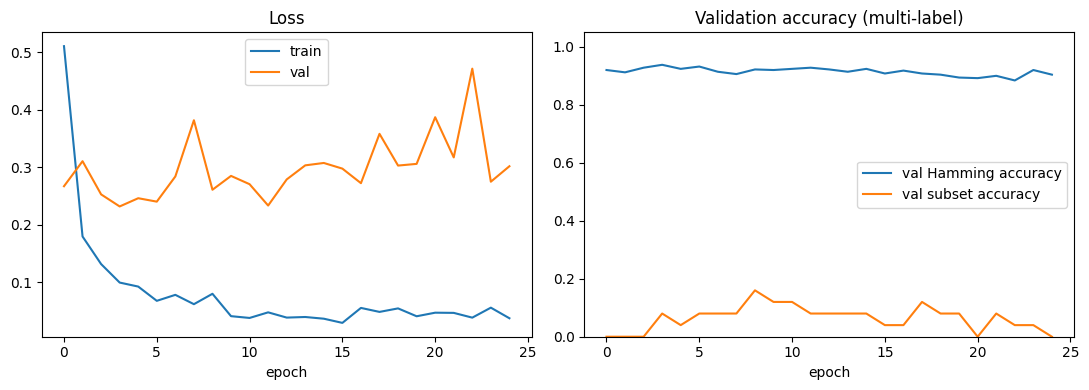

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(history["val_hamming_acc"], label="val Hamming accuracy")
ax[1].plot(history["val_subset_acc"], label="val subset accuracy")
ax[1].set_title("Validation accuracy (multi-label)")
ax[1].set_xlabel("epoch")
ax[1].set_ylim(0, 1.05)
ax[1].legend()
plt.tight_layout()
plt.show()

In [20]:
# Final evaluation on held-out TEST set (25 images)
ty, tp = collect_probs(model, test_loader)
test_metrics = multilabel_metrics(ty, tp)

vy_final, vp_final = collect_probs(model, val_loader)
val_metrics = multilabel_metrics(vy_final, vp_final)

results_df = pd.DataFrame([
    {"split": "validation (25)", **val_metrics},
    {"split": "test (25)", **test_metrics},
])
print("\n=== Final metrics (threshold=0.5) ===")
display(results_df)

print("\nInterpretation:")
print("- Hamming accuracy: fraction of label slots that are correct (20 labels × images).")
print("- Subset accuracy: fraction of images where all 20 labels match exactly.")


=== Final metrics (threshold=0.5) ===


,split,hamming_accuracy,subset_accuracy,precision_micro,recall_micro,f1_micro
0,validation (25),0.904,0.0,0.111111,0.058824,0.076923
1,test (25),0.882,0.0,0.100000,0.046512,0.063492



Interpretation:
- Hamming accuracy: fraction of label slots that are correct (20 labels × images).
- Subset accuracy: fraction of images where all 20 labels match exactly.


In [29]:
# Show per-image test predictions vs ground truth (first 10 test samples)
thr = 0.5
rows = []
for i in range(min(10, len(test_ds))):
    gt = ty[i]
    pr = (tp[i] >= thr).astype(int)
    gt_names = [VOC_CLASSES[j] for j in range(NUM_CLASSES) if gt[j] > 0.5]
    pred_names = [VOC_CLASSES[j] for j in range(NUM_CLASSES) if pr[j] == 1]
    rows.append({"test_idx": i, "ground_truth": ", ".join(gt_names) or "(none)", "predicted": ", ".join(pred_names) or "(none)"})

preview_df = pd.DataFrame(rows)
print("Sample test predictions:")
display(preview_df)

Sample test predictions:


,test_idx,ground_truth,predicted
0,0,cat,bird
1,1,"chair, diningtable",(none)
2,2,car,(none)
3,3,"car, cat",(none)
4,4,"bottle, chair, person, tvmonitor",(none)
5,5,"cat, pottedplant",bird
6,6,"chair, tvmonitor",bicycle
7,7,"boat, train",(none)
8,8,"bus, car",bicycle
9,9,train,"car, person"


### More test-set diagnostics

Multi-label VOC is evaluated **per class** (each class is its own binary problem). Below: **label-wise confusion counts**, a **pooled 2×2** confusion over all label slots, **precision / recall / F1** per class, and **micro-averaged PR + ROC** curves (using predicted probabilities).

ValueError: Found input variables with inconsistent numbers of samples: [500, 20]

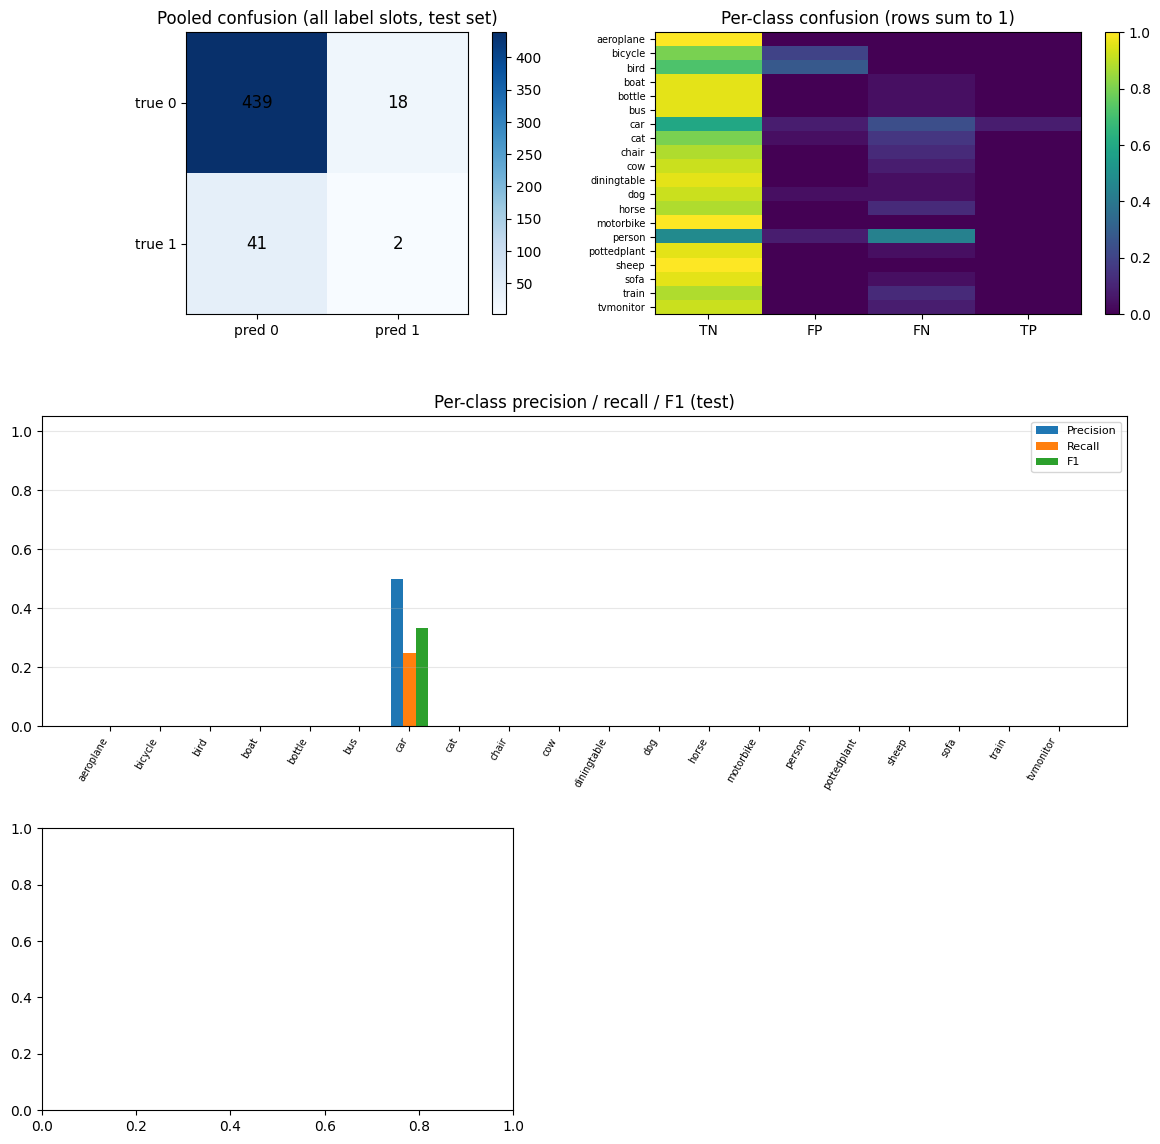

In [30]:
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    multilabel_confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_curve,
)

thr_eval = 0.5
y_true_t = ty.astype(np.int32)
y_pred_t = (tp >= thr_eval).astype(np.int32)

mcm = multilabel_confusion_matrix(y_true_t, y_pred_t)

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 1.1, 1.0], hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
cm_micro = confusion_matrix(y_true_t.ravel(), y_pred_t.ravel())
im1 = ax1.imshow(cm_micro, interpolation="nearest", cmap="Blues")
ax1.set_title("Pooled confusion (all label slots, test set)")
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(["pred 0", "pred 1"])
ax1.set_yticklabels(["true 0", "true 1"])
for ri in range(cm_micro.shape[0]):
    for ci in range(cm_micro.shape[1]):
        ax1.text(ci, ri, str(cm_micro[ri, ci]), ha="center", va="center", color="black", fontsize=12)
fig.colorbar(im1, ax=ax1, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
tn, fp, fn, tp = mcm[:, 0, 0], mcm[:, 0, 1], mcm[:, 1, 0], mcm[:, 1, 1]
hm = np.column_stack([tn, fp, fn, tp]).astype(float)
row_sum = hm.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1.0
hm_norm = hm / row_sum
im2 = ax2.imshow(hm_norm, aspect="auto", cmap="viridis")
ax2.set_yticks(np.arange(NUM_CLASSES))
ax2.set_yticklabels(VOC_CLASSES, fontsize=7)
ax2.set_xticks(np.arange(4))
ax2.set_xticklabels(["TN", "FP", "FN", "TP"])
ax2.set_title("Per-class confusion (rows sum to 1)")
fig.colorbar(im2, ax=ax2, fraction=0.046)

ax3 = fig.add_subplot(gs[1, :])
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
    y_true_t, y_pred_t, average=None, zero_division=0
)
x = np.arange(NUM_CLASSES)
w = 0.25
ax3.bar(x - w, prec_c, w, label="Precision")
ax3.bar(x, rec_c, w, label="Recall")
ax3.bar(x + w, f1_c, w, label="F1")
ax3.set_xticks(x)
ax3.set_xticklabels(VOC_CLASSES, rotation=60, ha="right", fontsize=7)
ax3.set_ylim(0, 1.05)
ax3.set_title("Per-class precision / recall / F1 (test)")
ax3.legend(loc="upper right", fontsize=8)
ax3.grid(axis="y", alpha=0.3)

ax4 = fig.add_subplot(gs[2, 0])
pr_mic, rc_mic, _ = precision_recall_curve(y_true_t.ravel(), tp.ravel())
ap_mic = average_precision_score(y_true_t.ravel(), tp.ravel())
ax4.plot(rc_mic, pr_mic)
ax4.set_xlabel("Recall")
ax4.set_ylabel("Precision")
ax4.set_title(f"Micro PR curve (average precision = {ap_mic:.3f})")
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1.05)
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
fpr_mic, tpr_mic, _ = roc_curve(y_true_t.ravel(), tp.ravel())
roc_auc = auc(fpr_mic, tpr_mic)
ax5.plot(fpr_mic, tpr_mic)
ax5.plot([0, 1], [0, 1], "k--", alpha=0.25)
ax5.set_xlabel("False positive rate")
ax5.set_ylabel("True positive rate")
ax5.set_title(f"Micro ROC (AUC = {roc_auc:.3f})")
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1.05)
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.show()

per_class_df = pd.DataFrame(
    {
        "class": VOC_CLASSES,
        "precision": prec_c,
        "recall": rec_c,
        "f1": f1_c,
        "support_true": sup_c,
        "tp": tp.astype(int),
        "fp": fp.astype(int),
        "fn": fn.astype(int),
        "tn": tn.astype(int),
    }
)
print("Per-class metrics & confusion counts (test):")
display(per_class_df.round(4))